### **[Building an Automatic Support & Resistance Detector in Python](https://medium.datadriveninvestor.com/i-tried-building-an-automatic-support-resistance-detector-in-python-heres-what-actually-worked-524686e3f667)**

In [1]:
!pip install -qq mplfinance yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 817.0 kB/s eta 0:00:00


#### **Download NIFTY Data**

In [2]:
import sys

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display

# =========================================================
# IMPORT LIBRARIES
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

import mplfinance as mpf

from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde

IN_COLAB = "google.colab" in sys.modules

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)

pd.set_option("display.precision", 4)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['figure.dpi'] = 150

%autosave 15

Autosaving every 15 seconds


In [3]:
# =========================================================
# DOWNLOAD DATA
# =========================================================
SYMBOL = "^NSEI"
df = yf.download(
  SYMBOL,
  period="6mo",
  interval="1d",
  auto_adjust=True,
  progress=False,
  multi_level_index=False
)
display(df.sample(10))

,Close,High,Low,Open,Volume
Date,,,,,
2026-01-07,26140.7500,26187.1504,26067.9004,26143.0996,338200
2026-01-12,25790.2500,25813.1504,25473.4004,25669.0508,275800
2025-11-11,25694.9492,25715.8008,25449.2500,25617.0000,297700
2026-01-23,25048.6504,25347.9492,25025.3008,25344.5996,393900
2025-12-11,25898.5508,25922.8008,25693.2500,25771.4004,206100
2026-02-06,25693.6992,25703.9492,25491.9004,25605.8008,375500
2026-02-19,25454.3496,25885.3008,25388.7500,25873.3496,298200
2025-11-19,26052.6504,26074.6504,25856.1992,25918.0996,250100
2026-01-01,26146.5508,26197.5508,26113.4004,26173.3008,425600


#### **Visualize Price and Daily Volatility**

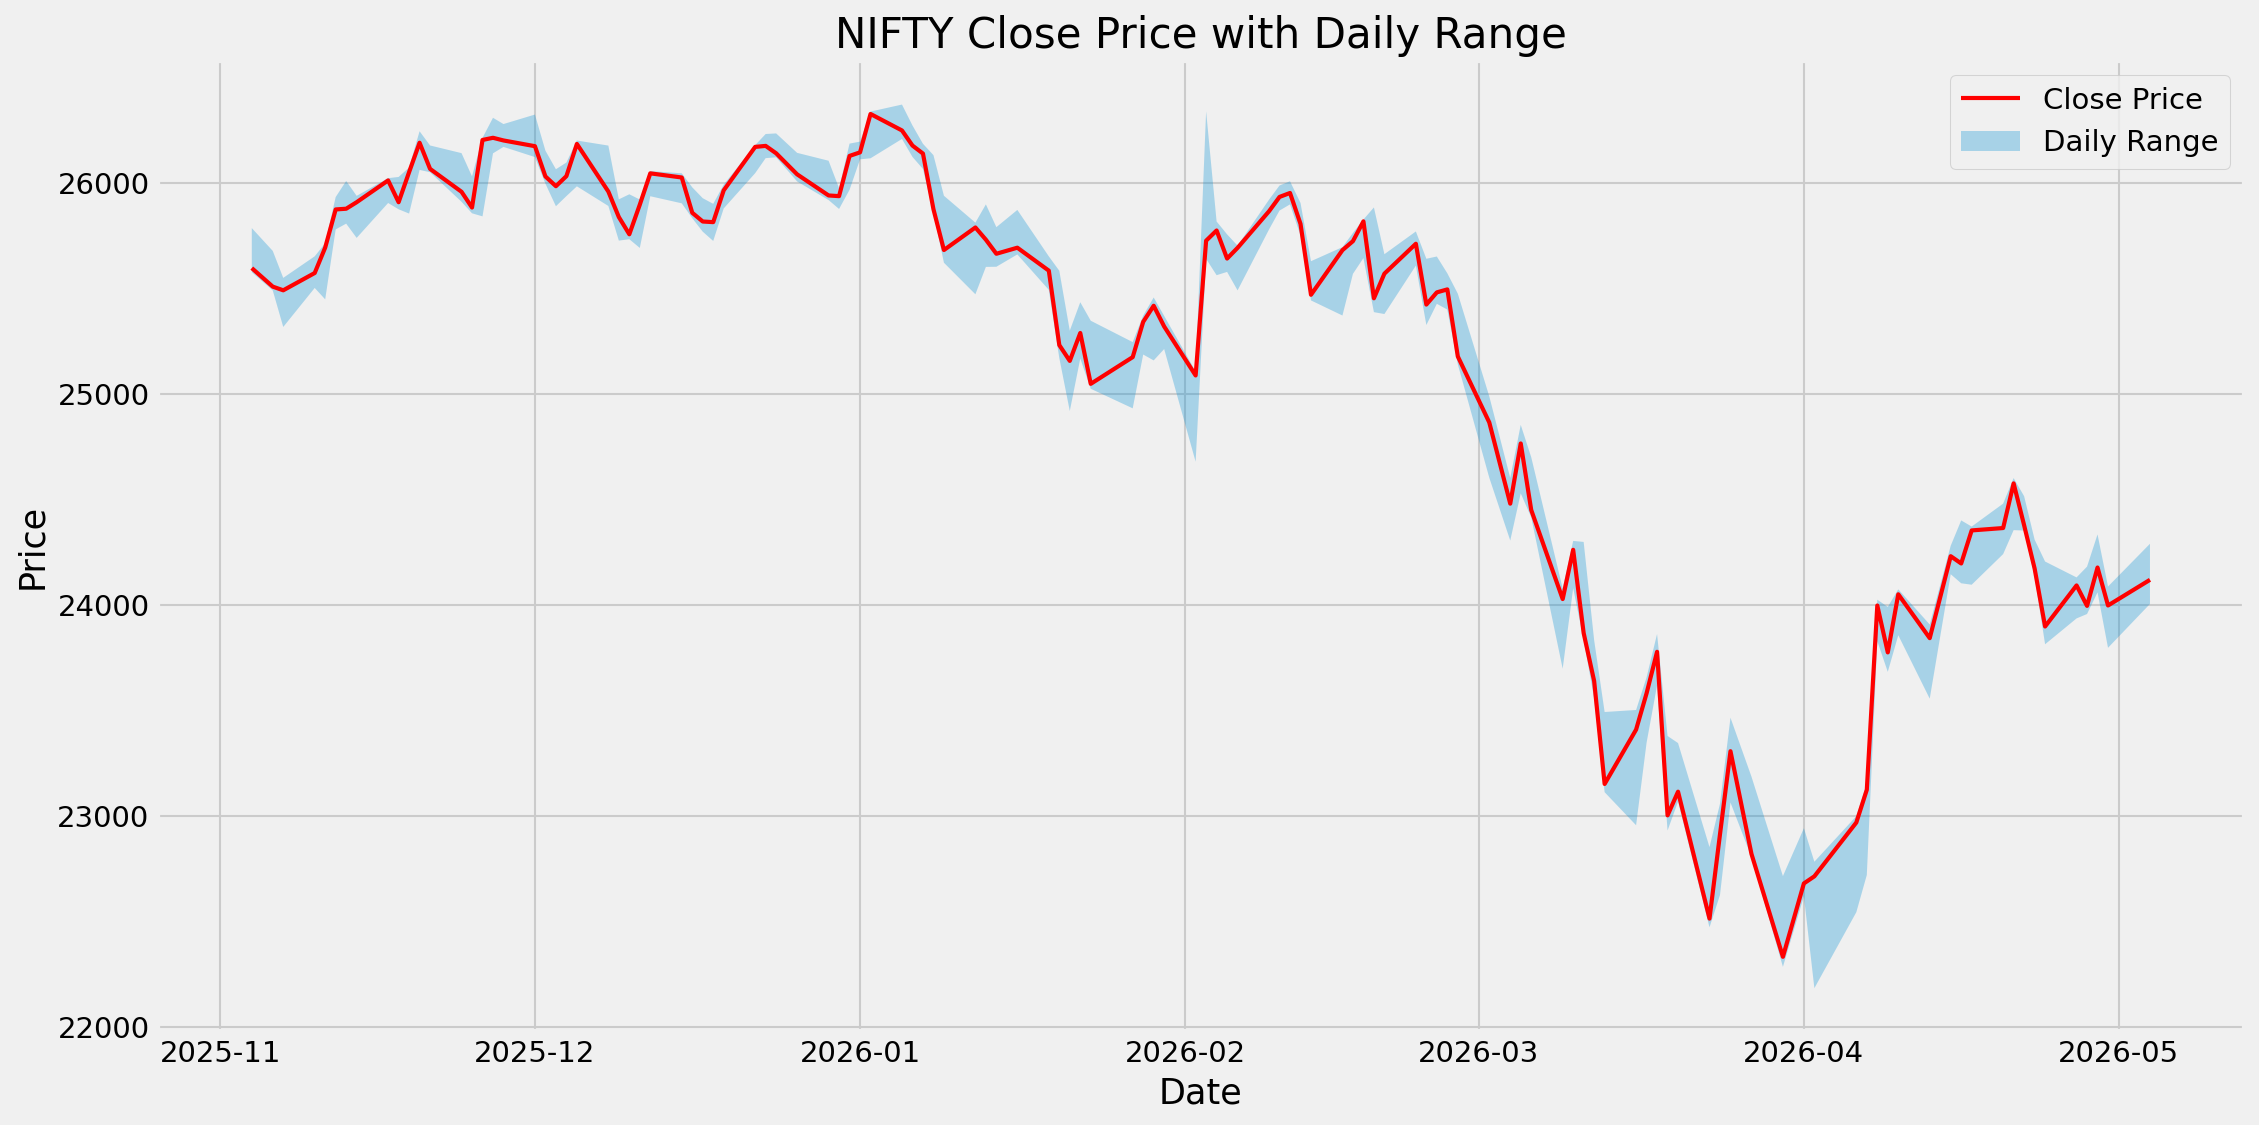

In [4]:
plt.figure(figsize=(16, 8))

# =========================================================
# CLOSE PRICE
# =========================================================
plt.plot(
  df.index,
  df["Close"],
  color="red",
  linewidth=2,
  label="Close Price"
)

# =========================================================
# DAILY RANGE
# =========================================================
plt.fill_between(
  df.index,
  df["Low"].squeeze(),
  df["High"].squeeze(),
  alpha=0.30,
  label="Daily Range"
)

# =========================================================
# FORMATTING
# =========================================================
plt.title("NIFTY Close Price with Daily Range")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

#### **Detect Swing Highs and Swing Lows**

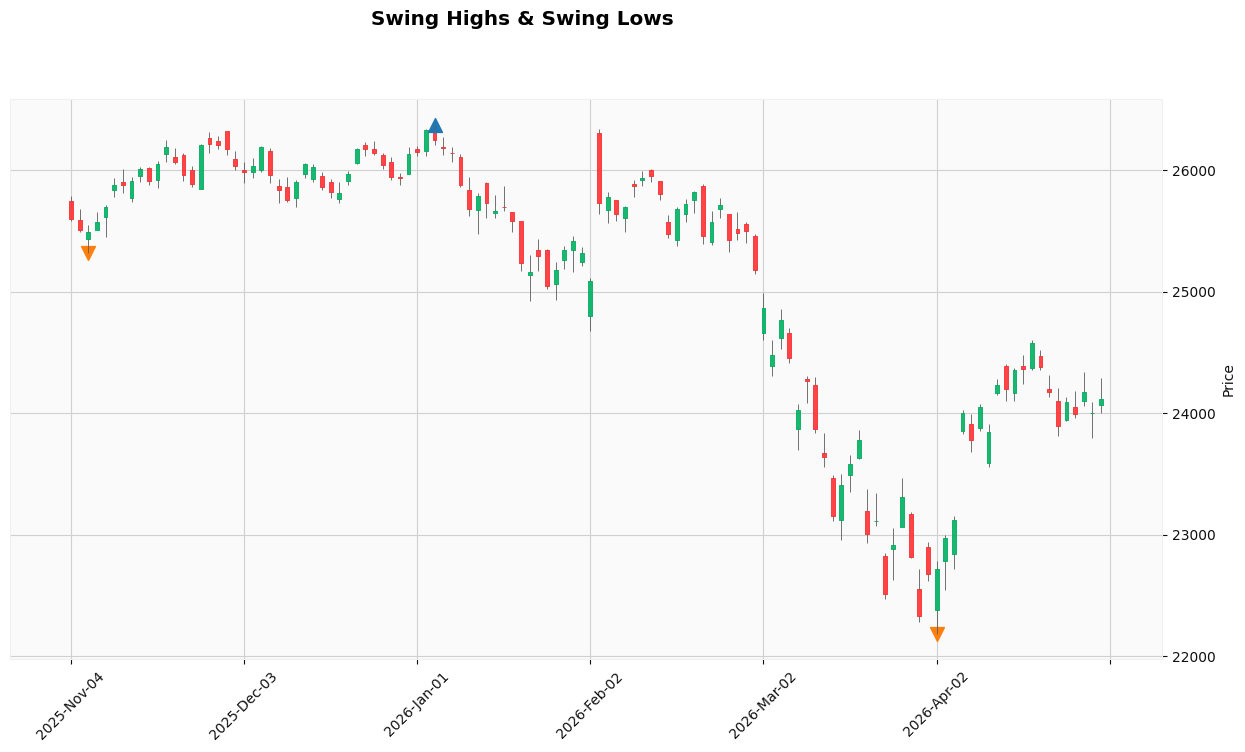

In [5]:
# =========================================================
# CREATE COPY
# =========================================================
plot_df = df.copy()

# =========================================================
# CLEAN DATAFRAME
# =========================================================
if isinstance(plot_df.columns, pd.MultiIndex):
    plot_df.columns = plot_df.columns.get_level_values(0)
plot_df.index = pd.to_datetime(plot_df.index)
cols = ["Open", "High", "Low", "Close", "Volume"]
for col in cols:
    plot_df[col] = pd.to_numeric(
        plot_df[col],
        errors="coerce"
    )
plot_df = plot_df.dropna()

# =========================================================
# FIND SWING HIGHS & LOWS
# =========================================================
SWING_WINDOW = 30
highs = plot_df["High"].values
lows = plot_df["Low"].values
local_max = argrelextrema(
    highs,
    np.greater_equal,
    order=SWING_WINDOW
)[0]
local_min = argrelextrema(
    lows,
    np.less_equal,
    order=SWING_WINDOW
)[0]

# =========================================================
# CREATE FULL-LENGTH ARRAYS
# =========================================================
swing_highs = np.full(len(plot_df), np.nan)
swing_lows = np.full(len(plot_df), np.nan)
swing_highs[local_max] = highs[local_max]
swing_lows[local_min] = lows[local_min]

# =========================================================
# CREATE ADDPLOTS
# =========================================================
apds = [
    mpf.make_addplot(
        swing_highs,
        type='scatter',
        marker='^',
        markersize=100
    ),
    mpf.make_addplot(
        swing_lows,
        type='scatter',
        marker='v',
        markersize=100
    )
]

# =========================================================
# PLOT
# =========================================================
mpf.plot(
    plot_df,
    type='candle',
    style='yahoo',
    figsize=(16, 8),
    addplot=apds,
    title='Swing Highs & Swing Lows',
    ylabel='Price',
    volume=False
)

#### **Plot Local Support & Resistance Zones**

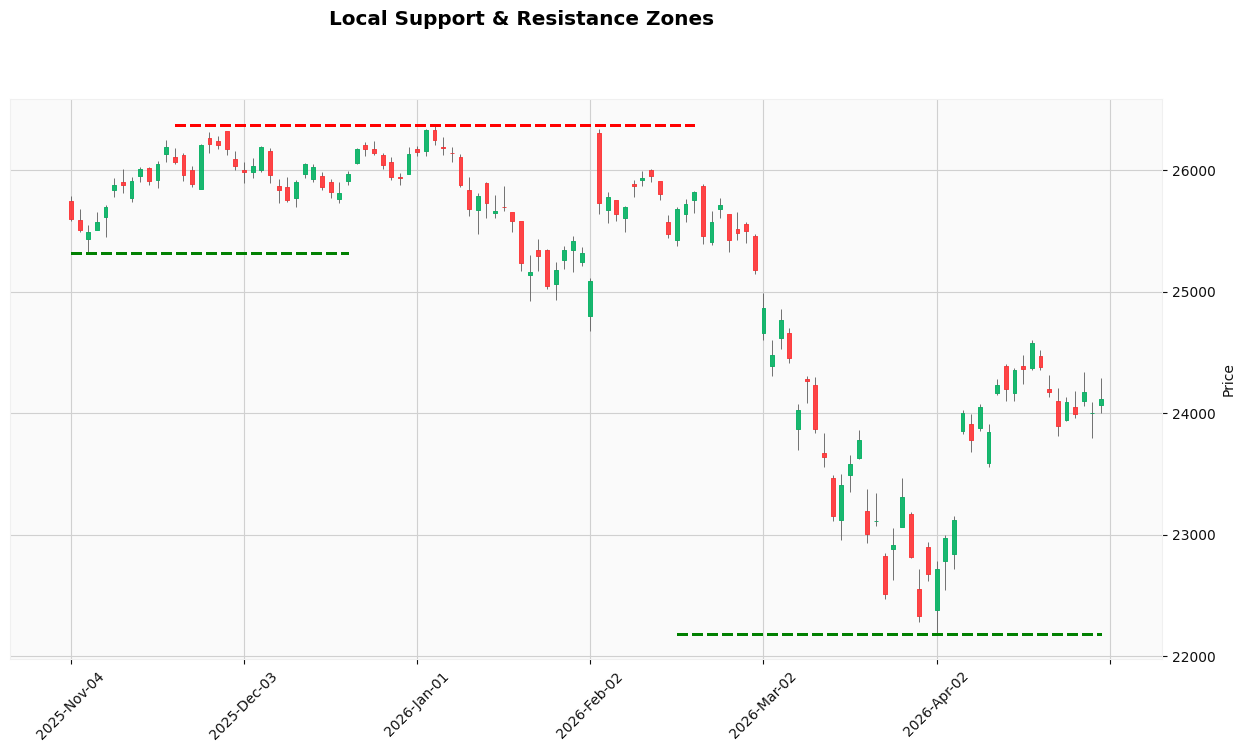

In [6]:
# =========================================================
# CREATE LINE SEGMENTS
# =========================================================
lines = []
colors = []

# ---------------------------------------------------------
# RESISTANCE LINES
# ---------------------------------------------------------
for idx in local_max:
  level = highs[idx]
  start = max(0, idx - SWING_WINDOW)
  end = min(len(plot_df) - 1, idx + SWING_WINDOW)
  lines.append([
    (plot_df.index[start], level),
    (plot_df.index[end], level)
  ])
  colors.append('red')

# ---------------------------------------------------------
# SUPPORT LINES
# ---------------------------------------------------------
for idx in local_min:
  level = lows[idx]
  start = max(0, idx - SWING_WINDOW)
  end = min(len(plot_df) - 1, idx + SWING_WINDOW)
  lines.append([
    (plot_df.index[start], level),
    (plot_df.index[end], level)
  ])
  colors.append('green')

# =========================================================
# PLOT
# =========================================================
mpf.plot(
  plot_df,
  type='candle',
  style='yahoo',
  figsize=(16, 8),
  title='Local Support & Resistance Zones',
  ylabel='Price',
  volume=False,
  alines=dict(
    alines=lines,
    colors=colors,
    linestyle='--',
    linewidths=2
  )
)

#### **Cluster Nearby Price Levels**

In [7]:
# =========================================================
# PARAMETERS
# =========================================================

CLUSTER_DISTANCE = 0.005
# =========================================================
# CREATE RAW LEVELS
# =========================================================
all_levels = []
# Resistance Levels
for idx in local_max:
    all_levels.append({
        "type": "R",
        "price": highs[idx],
        "index": idx
    })
# Support Levels
for idx in local_min:
    all_levels.append({
        "type": "S",
        "price": lows[idx],
        "index": idx
    })
# =========================================================
# SORT LEVELS
# =========================================================
all_levels = sorted(
  all_levels,
  key=lambda x: x["price"]
)

# =========================================================
# CLUSTER LEVELS
# =========================================================
clusters = []
for lvl in all_levels:
  placed = False
  for cluster in clusters:
    avg_price = np.mean(cluster["prices"])
    if abs(
      lvl["price"] - avg_price
    ) / avg_price < CLUSTER_DISTANCE:
      cluster["prices"].append(
          lvl["price"]
      )
      cluster["types"].append(
          lvl["type"]
      )
      cluster["indices"].append(
          lvl["index"]
      )
      placed = True
      break
  if not placed:
    clusters.append({
      "prices": [lvl["price"]],
      "types": [lvl["type"]],
      "indices": [lvl["index"]]
    })

#### **Build Clustered Support & Resistance Zones**

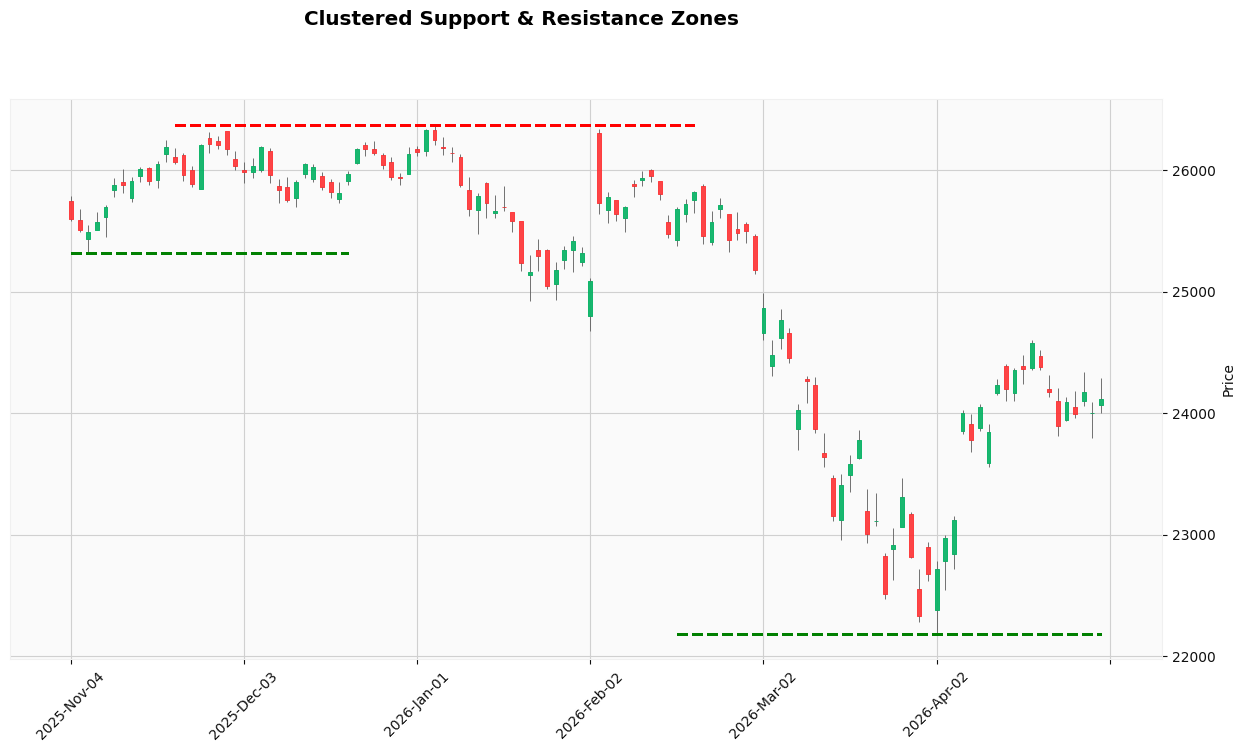

In [8]:
# =========================================================
# BUILD CLUSTERED LINES
# =========================================================

lines = []
colors = []
for cluster in clusters:
  avg_price = np.mean(
    cluster["prices"]
  )
  support_count = cluster["types"].count("S")
  resistance_count = cluster["types"].count("R")
  color = "green" if support_count > resistance_count else "red"
  start_idx = min(cluster["indices"])
  end_idx = max(cluster["indices"])
  start_idx = max(
    0,
    start_idx - SWING_WINDOW
  )
  end_idx = min(
    len(plot_df) - 1,
    end_idx + SWING_WINDOW
  )
  lines.append([
    (plot_df.index[start_idx], avg_price),
    (plot_df.index[end_idx], avg_price)
  ])
  colors.append(color)

# =========================================================
# PLOT CLUSTERED LEVELS
# =========================================================
mpf.plot(
  plot_df,
  type='candle',
  style='yahoo',
  figsize=(16, 8),
  title='Clustered Support & Resistance Zones',
  ylabel='Price',
  volume=False,
  alines=dict(
    alines=lines,
    colors=colors,
    linestyle='--',
    linewidths=2
  )
)

#### **Build a Support/Resistance Density Gradient**

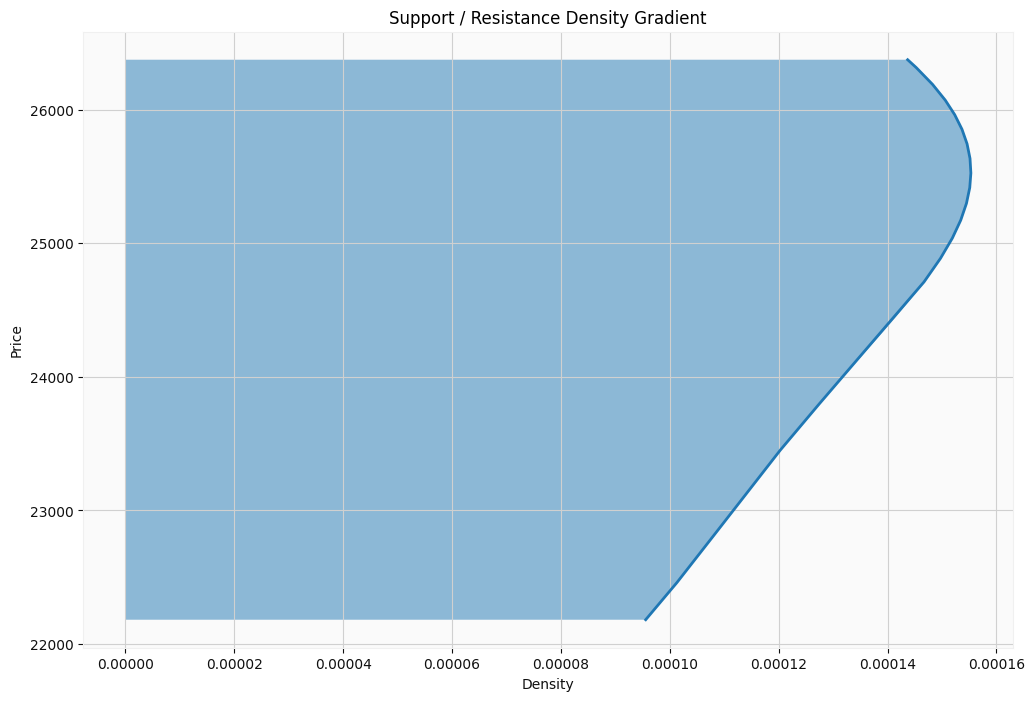

In [9]:
# =========================================================
# EXTRACT PRICES
# =========================================================
prices = np.array([
  lvl["price"]
  for lvl in all_levels
])

# =========================================================
# KDE DENSITY ESTIMATION
# =========================================================
density = gaussian_kde(prices)
price_range = np.linspace(
  prices.min(),
  prices.max(),
  500
)
density_values = density(price_range)

# =========================================================
# PLOT DENSITY GRADIENT
# =========================================================
plt.figure(figsize=(12, 8))
plt.plot(
  density_values,
  price_range,
  linewidth=2
)
plt.fill_betweenx(
  price_range,
  density_values,
  alpha=0.5
)
plt.title("Support / Resistance Density Gradient")
plt.xlabel("Density")
plt.ylabel("Price")
plt.grid(True)
plt.show()